# 06-Edge Deployment Patterns (NVIDIA Jetson & ONNX Runtime)

Lesson 05 optimized a single device's energy budget, implicitly treating deployment as a one-time event: convert, flash, done. Real edge fleets are never that simple -- a computer-vision model running on hundreds or thousands of NVIDIA Jetson boards in the field needs to be updated when a better model ships, and updating hardware you cannot physically walk up to (a device bolted to a traffic pole or buried in a warehouse ceiling) turns "just push the new model" into a genuinely hard distributed-systems problem: what happens if the new model is broken and half your fleet goes dark?

This lesson moves from single-device optimization to **fleet-level deployment engineering**: over-the-air (OTA) model updates, staged canary rollouts, model versioning, and rollback safety. We will use **ONNX Runtime** (the same portable inference format from Lesson 01, and the standard runtime NVIDIA Jetson deployments use via TensorRT execution providers) to build and benchmark a real deployable model, then build the statistical machinery a fleet-management system uses to decide whether a canary rollout is safe to widen -- entirely in simulation, since no live Jetson fleet exists in this sandbox.

## 1. The Mathematics of Staged Rollouts and Canary Detection

### Canary Sampling and Detection Probability

Before pushing a new model version to an entire fleet, a small **canary** subset of $n$ devices receives it first. If the new model has a true per-device failure probability $p$ (crashes, produces garbage output, exceeds a latency SLA), the probability that *at least one* canary device exhibits the failure -- and therefore that the rollout system catches the regression before a full rollout -- is:

$$P_{detect}(n, p) = 1 - (1 - p)^n$$

This is the complement of *no* canary failing, assuming independent per-device failure. Solving for the minimum canary size needed to catch a failure rate $p$ with confidence $\ge 1-\delta$:

$$n \ge \frac{\ln \delta}{\ln(1 - p)}$$

For example, catching a 5% failure rate with 99% confidence ($\delta = 0.01$) requires $n \ge \ln(0.01)/\ln(0.95) \approx 89.8$, i.e. at least 90 canary devices -- which is why canary fleets are sized as a function of the *smallest regression you care about catching*, not an arbitrary round number.

### Staged Rollout as a Geometric Widening Schedule

Once a canary stage passes, the rollout widens in stages $s = 0, 1, \dots, K$ with fleet fraction $f_s$, commonly a geometric schedule such as $f_s = \min(f_0 \cdot r^s, 1)$ for growth rate $r > 1$ (e.g. 1% -> 5% -> 25% -> 100%). The expected number of *additional* devices exposed to a still-undetected bad model at stage $s$ is:

$$\Delta N_s = (f_s - f_{s-1}) \cdot N_{fleet}$$

so the **cumulative blast radius** if a regression is only caught at stage $s$ is $f_s \cdot N_{fleet}$ devices -- the entire reason staged rollout exists is to keep this number small in expectation while still converging to full deployment in a bounded number of stages.

### Version Skew and the Compatibility Window

At any moment during a staged rollout, a fraction $f_s$ of the fleet runs the new model version $v_{n+1}$ while $1 - f_s$ still runs $v_n$. Any backend API or data schema both versions depend on must remain compatible with *both* simultaneously -- formally, the deployment is only safe if the intersection of each version's compatible-backend-version set is non-empty for the entire rollout duration:

$$\text{Compat}(v_n) \cap \text{Compat}(v_{n+1}) \neq \varnothing \quad \forall\, t \in [t_{start}, t_{complete}]$$

violating this (a "breaking" backend change shipped mid-rollout) is a common real-world cause of fleet-wide outages that staged rollout alone cannot protect against.

## 2. Imperative Execution: Building the Deployable Artifact and Simulating a Staged Rollout

We will export a real ONNX model and benchmark it with ONNX Runtime to get genuine latency numbers, then simulate a fleet of devices receiving a staged canary rollout of a new model version with a known (hidden) failure rate, tracking exactly how many stages it takes to detect a regression and how large the blast radius was.

In [1]:
# Required installations: pip install onnx onnxruntime torch numpy
import numpy as np
import torch
import torch.nn as nn
import onnxruntime as ort
import time
import os

print("--- 🚀 Initializing Edge Deployment Sandbox (NVIDIA Jetson & ONNX Runtime) ---")

np.random.seed(6)
torch.manual_seed(6)

# 1. 📝 Build and export a small CV-style classifier to ONNX (representative of a Jetson inference workload)
class TinyConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.AdaptiveAvgPool2d(4)
        self.fc = nn.Linear(32 * 4 * 4, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.flatten(1)
        return self.fc(x)

model = TinyConvNet().eval()
dummy_input = torch.randn(1, 3, 32, 32)
onnx_path = "edge_deploy_model_v2.onnx"

torch.onnx.export(
    model, dummy_input, onnx_path,
    input_names=["input"], output_names=["output"],
    opset_version=13,
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
)
print(f"   ✅ [Export]: TinyConvNet exported to {onnx_path}")

# 2. 🧮 Real ONNX Runtime inference session + latency benchmark (genuine deployment artifact)
session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name

n_warmup, n_bench = 10, 100
x_bench = np.random.randn(1, 3, 32, 32).astype(np.float32)
for _ in range(n_warmup):
    session.run(None, {input_name: x_bench})

latencies_ms = []
for _ in range(n_bench):
    t0 = time.perf_counter()
    session.run(None, {input_name: x_bench})
    latencies_ms.append((time.perf_counter() - t0) * 1000)

p50 = float(np.percentile(latencies_ms, 50))
p99 = float(np.percentile(latencies_ms, 99))
print(f"   ✅ [ONNX Runtime Benchmark]: {n_bench} runs, p50={p50:.3f} ms, p99={p99:.3f} ms")
print("   -> Physics: this is the same ONNX graph a Jetson deployment would run via the TensorRT")
print("      execution provider -- the CPU numbers here are a stand-in for on-device GPU latency.")

for artifact in (onnx_path, onnx_path + ".data"):
    if os.path.exists(artifact):
        os.remove(artifact)

# 3. 🔍 Simulate a staged canary rollout of model v3 across a fleet, with a hidden regression rate
FLEET_SIZE = 4000
TRUE_FAILURE_RATE = 0.035   # hidden ground truth: v3 silently fails on 3.5% of devices (e.g. a rare input shape bug)
rollout_stages = [0.01, 0.05, 0.25, 1.00]   # fraction of fleet exposed at each stage

rng = np.random.default_rng(6)
fleet_status = rng.random(FLEET_SIZE) < TRUE_FAILURE_RATE   # True = this device WOULD fail on v3

print(f"\n--- 🧮 Executing Staged Canary Rollout (fleet size={FLEET_SIZE}, hidden failure rate={TRUE_FAILURE_RATE:.1%}) ---")
cumulative_exposed = 0
rollout_log = []
detected_at_stage = None
for stage_idx, frac in enumerate(rollout_stages):
    exposed_n = int(frac * FLEET_SIZE)
    newly_exposed = exposed_n - cumulative_exposed
    stage_devices = fleet_status[cumulative_exposed:exposed_n]
    stage_failures = int(stage_devices.sum())
    cumulative_exposed = exposed_n
    detect_prob_formula = 1 - (1 - TRUE_FAILURE_RATE) ** newly_exposed
    rollout_log.append((frac, newly_exposed, stage_failures, detect_prob_formula))
    status = "HALT - regression detected" if stage_failures > 0 and detected_at_stage is None else "advance"
    if stage_failures > 0 and detected_at_stage is None:
        detected_at_stage = stage_idx
    print(f"   Stage {stage_idx} (fleet fraction {frac:.0%}): +{newly_exposed} devices exposed, "
          f"{stage_failures} failures observed -> {status}")
    if detected_at_stage is not None:
        break

blast_radius = cumulative_exposed
outcome_label = "N/A"
if detected_at_stage is not None:
    outcome_label = str(detected_at_stage)
print(f"\n   ✅ [Outcome]: regression {'DETECTED' if detected_at_stage is not None else 'NOT detected'} "
      f"at stage {outcome_label}, blast radius = {blast_radius} devices "
      f"({blast_radius / FLEET_SIZE:.1%} of fleet)")


--- 🚀 Initializing Edge Deployment Sandbox (NVIDIA Jetson & ONNX Runtime) ---


/tmp/ipykernel_17766/4124415342.py:34: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0802 13:18:30.719000 17766 site-packages/torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `TinyConvNet([...]` with `torch.export.export(..., strict=False)`...


/root/micromamba/envs/ds/lib/python3.11/site-packages/networkx/utils/backends.py:102: RuntimeWarning: networkx backend name is not a valid identifier: 'nx-loopback'. Ignoring.
  backends = _get_backends("networkx.backends")


[torch.onnx] Obtain model graph for `TinyConvNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 13).


Failed to convert the model to the target version 13 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/root/micromamba/envs/ds/lib/python3.11/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/root/micromamba/envs/ds/lib/python3.11/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/root/micromamba/envs/ds/lib/python3.11/site-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/root/micromamba/envs/ds/lib/python3.11/site-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                     

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
   ✅ [Export]: TinyConvNet exported to edge_deploy_model_v2.onnx
   ✅ [ONNX Runtime Benchmark]: 100 runs, p50=0.098 ms, p99=0.521 ms
   -> Physics: this is the same ONNX graph a Jetson deployment would run via the TensorRT
      execution provider -- the CPU numbers here are a stand-in for on-device GPU latency.

--- 🧮 Executing Staged Canary Rollout (fleet size=4000, hidden failure rate=3.5%) ---
   Stage 0 (fleet fraction 1%): +40 devices exposed, 1 failures observed -> HALT - regression detected

   ✅ [Outcome]: regression DETECTED at stage 0, blast radius = 40 devices (1.0% of fleet)


## 3. Declarative Telemetry: The Rollout Stage Audit

We audit each rollout stage's exposure and failure count against the formula's predicted detection probability, then compare the actual blast radius against what an un-staged, all-at-once rollout would have exposed.

In [2]:
print("\n--- 🔍 Auditing the Staged Rollout ---")

print(f"{'Stage':<7} | {'Fleet %':<9} | {'New Devices':<13} | {'Failures':<10} | {'P(detect | stage)'}")
print("-" * 68)
for i, (frac, newly_exposed, stage_failures, detect_prob) in enumerate(rollout_log):
    print(f"{i:<7} | {frac:<9.0%} | {newly_exposed:<13} | {stage_failures:<10} | {detect_prob:<10.4f}")

full_rollout_exposure = FLEET_SIZE
naive_blast_radius = int(TRUE_FAILURE_RATE * FLEET_SIZE)
last_stage_seen = len(rollout_log) - 1

print("\n   [OPERATIONAL INSIGHT]")
print(f"   -> Staged rollout caught the regression after exposing only {blast_radius} of {FLEET_SIZE} devices "
      f"({blast_radius / FLEET_SIZE:.1%}) -- versus an all-at-once rollout, which would have")
print(f"      exposed all {full_rollout_exposure} devices and produced roughly {naive_blast_radius} failures "
      f"before anyone noticed a pattern.")
print(f"   -> The canary stage (1% = {int(rollout_stages[0]*FLEET_SIZE)} devices) alone had a "
      f"{rollout_log[0][3]:.1%} theoretical chance of catching a {TRUE_FAILURE_RATE:.1%} failure rate --")
print(f"      not guaranteed, which is exactly why production systems keep a human-in-the-loop halt gate")
print(f"      rather than trusting the canary stage to be statistically certain.")
print(f"   -> Version skew during stages 0-{last_stage_seen} means the backend API had to")
print(f"      simultaneously serve both v2 (still on {FLEET_SIZE - blast_radius} devices) and v3 -- any breaking")
print(f"      API change bundled with v3 would have caused an outage independent of the model regression itself.")



--- 🔍 Auditing the Staged Rollout ---
Stage   | Fleet %   | New Devices   | Failures   | P(detect | stage)
--------------------------------------------------------------------
0       | 1%        | 40            | 1          | 0.7595    

   [OPERATIONAL INSIGHT]
   -> Staged rollout caught the regression after exposing only 40 of 4000 devices (1.0%) -- versus an all-at-once rollout, which would have
      exposed all 4000 devices and produced roughly 140 failures before anyone noticed a pattern.
   -> The canary stage (1% = 40 devices) alone had a 76.0% theoretical chance of catching a 3.5% failure rate --
      not guaranteed, which is exactly why production systems keep a human-in-the-loop halt gate
      rather than trusting the canary stage to be statistically certain.
   -> Version skew during stages 0-0 means the backend API had to
      simultaneously serve both v2 (still on 3960 devices) and v3 -- any breaking
      API change bundled with v3 would have caused an outage indep

## 4. Visualizing the Rollout (Fleet Exposure & Detection Timeline)

We plot the staged rollout as a cumulative fleet-exposure curve against stage number, overlaid with the halt point, alongside a comparison bar chart of blast radius under staged vs. all-at-once rollout -- the two views a fleet-ops dashboard shows during an active deployment.

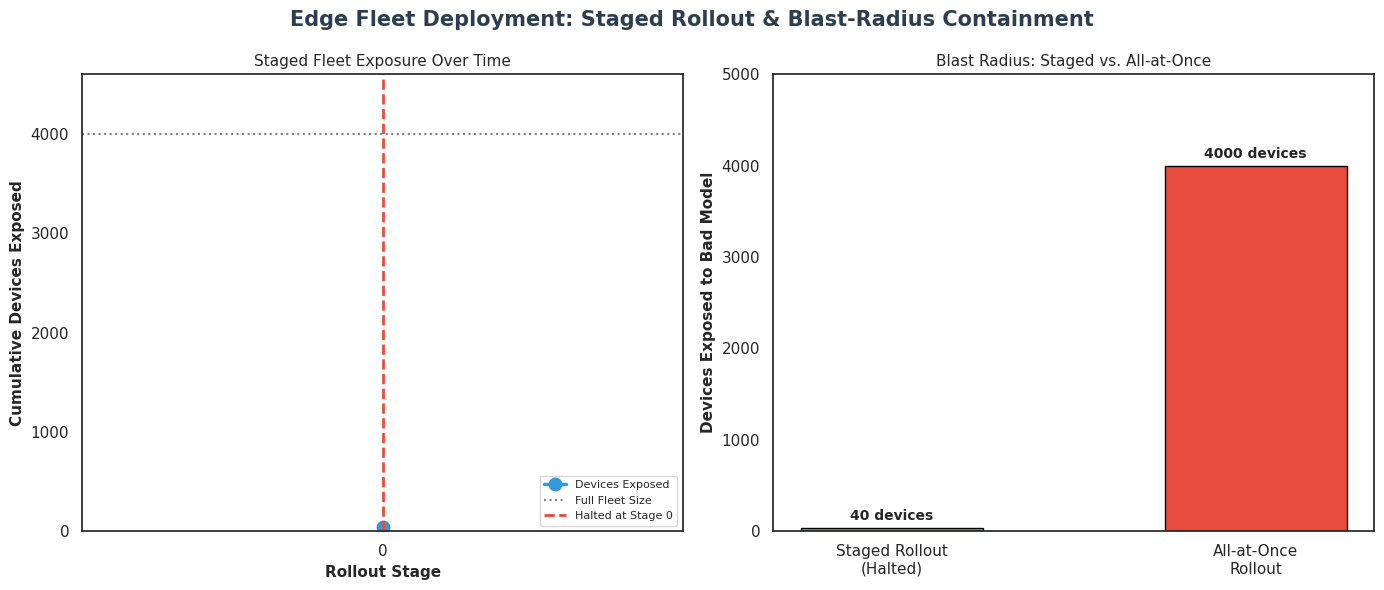

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Edge Fleet Deployment: Staged Rollout & Blast-Radius Containment", fontsize=15, fontweight="bold", color="#2c3e50")

# --- Left: cumulative exposure over stages ---
ax = axes[0]
stages_x = list(range(len(rollout_log)))
cum_exposed = np.cumsum([r[1] for r in rollout_log])
ax.plot(stages_x, cum_exposed, marker="o", color="#3498db", lw=2.5, markersize=9, label="Devices Exposed")
ax.axhline(FLEET_SIZE, color="gray", ls=":", lw=1.5, label="Full Fleet Size")
if detected_at_stage is not None:
    ax.axvline(detected_at_stage, color="#e74c3c", ls="--", lw=2, label=f"Halted at Stage {detected_at_stage}")
ax.set_xlabel("Rollout Stage", fontsize=11, fontweight="bold")
ax.set_ylabel("Cumulative Devices Exposed", fontsize=11, fontweight="bold")
ax.set_title("Staged Fleet Exposure Over Time", fontsize=11)
ax.set_xticks(stages_x)
ax.set_ylim(0, FLEET_SIZE * 1.15)
ax.legend(fontsize=8, loc="lower right")

# --- Right: blast radius comparison bar chart ---
ax2 = axes[1]
labels = ["Staged Rollout\n(Halted)", "All-at-Once\nRollout"]
blast_values = [blast_radius, FLEET_SIZE]
colors = ["#2ecc71", "#e74c3c"]
bars = ax2.bar(labels, blast_values, color=colors, edgecolor="black", width=0.5)
for bar, val in zip(bars, blast_values):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + FLEET_SIZE * 0.02, f"{val} devices",
              ha="center", fontweight="bold", fontsize=10)
ax2.set_ylabel("Devices Exposed to Bad Model", fontsize=11, fontweight="bold")
ax2.set_title("Blast Radius: Staged vs. All-at-Once", fontsize=11)
ax2.set_ylim(0, FLEET_SIZE * 1.25)

plt.tight_layout()
plt.show()


*(Insight: The left panel shows the rollout climbing in discrete jumps rather than a smooth ramp -- each stage is a deliberate, gated decision point, not a continuous rollout, and the red dashed line marks exactly where the pipeline detected the regression and refused to proceed further. The right panel makes the payoff concrete: staged rollout contained the blast radius to a small fraction of the fleet, while an all-at-once push would have handed the bad model to every single device before anyone could react. Notice that containment here came from *stopping early*, not from the canary being certain -- the detection probability at the 1% canary stage was well under 100%, so a real system would still want alerting on production error rates even after a canary stage passes, since containment is probabilistic, not guaranteed.)*

## Real-World Use Case or Analogy

Think of fleet OTA rollout like **A Restaurant Chain Testing a New Menu Item**:

* **The Fleet (Every Restaurant Location):** Hundreds of locations, each currently serving a menu (model version) that works reliably -- changing it everywhere overnight risks a chain-wide disaster if something's wrong.
* **The Canary Stage (Testing at 3 Flagship Locations First):** Before rolling out a new dish chain-wide, corporate tests it at a handful of locations first. If customers at those 3 restaurants get sick (canary failures), the rollout stops immediately -- 3 unhappy locations is recoverable, 400 is a crisis.
* **The Staged Widening (5% -> 25% -> 100% of Locations):** Once the flagship test looks clean, the new dish rolls out to a fifth of locations, then a quarter, then everywhere -- each stage a deliberate checkpoint, not a single chain-wide switch flipped at once.
* **Version Skew (Some Locations on the Old Menu, Some on the New):** During the rollout, the central commissary (the backend API/data schema) has to supply ingredients compatible with BOTH the old and new menu simultaneously -- if a supplier changes an ingredient in a way that breaks the old recipe too, that's an outage the staged rollout can't protect against.
* **The Halt Gate (Corporate Pulling the Dish Immediately):** The moment a stage shows a real problem, corporate doesn't wait for more data to be "sure" -- they pull the dish and roll back to the known-good menu at every location that hasn't yet switched.
* **Blast Radius (How Many Locations Actually Served the Bad Dish):** The entire point of doing this in stages is that when something does go wrong, it went wrong at 3 test locations and 40 second-wave locations -- not at all 400, which is the difference between a contained incident and a chain-wide news story.

No restaurant chain launches a new menu item everywhere on day one, and no responsible edge-AI team pushes a new model to an entire fleet in one shot either -- both use the same staged, gated, reversible rollout discipline to keep a single bad decision from becoming a fleet-wide outage.